In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [168]:
artist_exposures = pd.read_csv("experiments/babyLFM5k/results/artist_exposures.csv")

In [169]:
artist_exposures.head()

,artist,country,gender,train_popularity,iteration_1_exposure,iteration_2_exposure,iteration_3_exposure,iteration_4_exposure,iteration_5_exposure,iteration_6_exposure,iteration_7_exposure,iteration_8_exposure,iteration_9_exposure,iteration_10_exposure,iteration_11_exposure,iteration_12_exposure,iteration_13_exposure,iteration_14_exposure,iteration_15_exposure
0,Miguel,ES,Male,0.000044,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1,Britney Spears,US,Female,0.015442,0.049147,0.048240,0.025655,0.016719,0.011547,0.006974,0.00669,0.007022,0.010722,0.009859,0.011418,0.023689,0.024426,0.03695,0.020829
2,J. Cole,US,Male,0.000800,0.000966,0.000279,0.000083,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
3,Miley Cyrus,US,Non-binary,0.003664,0.000075,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
4,Amerie,US,Female,0.000509,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000157,0.00000,0.000000


In [170]:
language_data = pd.read_csv("experiments/babyLFM5k/input/merged_language_data_all.csv")

In [171]:
artist_language_matching = (
    language_data.groupby("artist")["language"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)
artist_language_matching = artist_language_matching[artist_language_matching["artist"].isin(artist_exposures["artist"])]

In [172]:
artist_language_matching["artist"].nunique()

1739

In [173]:
artist_exposures.shape

(1906, 19)

In [174]:
artist_language_matching.to_csv("experiments/babyLFM5k/input/artist_language_matching.csv", index=False)

In [175]:
countries_exposures = artist_exposures.iloc[:, [1] + list(range(3, artist_exposures.shape[1]))].groupby("country").sum()

In [176]:
english_countries = countries_exposures.index.isin(["AU","CA","UK","US"])

In [177]:
# Load catalog representation
tracks_catalog = pd.read_csv("experiments/babyLFM5k/input/tracks.tsv", sep="\t", header=None, names=["track_id","artist","title","country","gender"])
catalog_countries_representation = tracks_catalog.groupby("country").size() / len(tracks_catalog)

# Calculate catalog proportions for each region
english_countries_list = ["AU","CA","UK","US"]
spanish_countries_list = ["ES","MX","AR","CO","CL","PE","VE","EC","BO","PY","UY"]
german_countries_list = ["DE","AT","CH","LI"]

english_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(english_countries_list)].sum()
spanish_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(spanish_countries_list)].sum()
german_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(german_countries_list)].sum()

print(f"English-speaking countries catalog representation: {english_catalog_prop:.3f}")
print(f"Spanish-speaking countries catalog representation: {spanish_catalog_prop:.3f}")
print(f"German-speaking countries catalog representation: {german_catalog_prop:.3f}")

English-speaking countries catalog representation: 0.741
Spanish-speaking countries catalog representation: 0.026
German-speaking countries catalog representation: 0.018


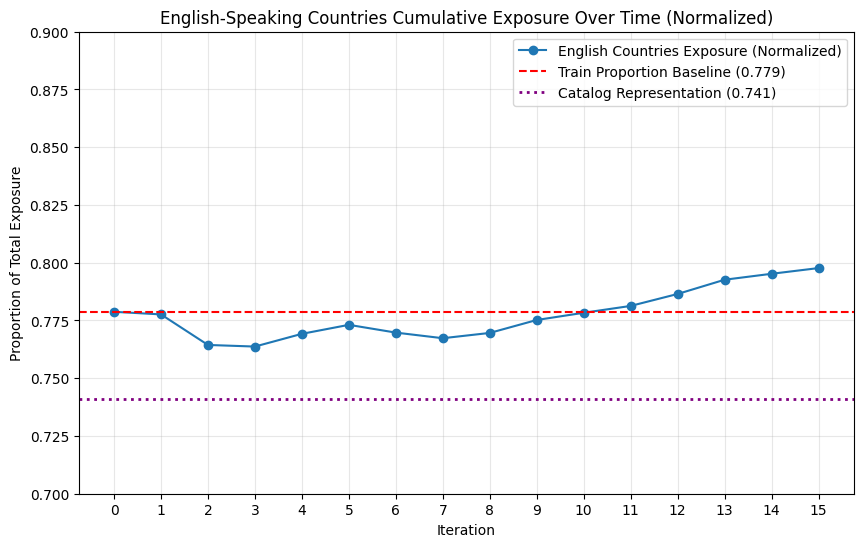

In [178]:
# Plot normalized cumulative exposure of English countries over time
exposure_over_time = countries_exposures[english_countries].sum(axis=0)
cumulative_exposure = exposure_over_time.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative = cumulative_exposure / total_cumulative

# Calculate train proportion baseline from train_popularity in artist_exposures
english_train_popularity = artist_exposures[artist_exposures['country'].isin(english_countries_list)]['train_popularity'].sum()
total_train_popularity = artist_exposures['train_popularity'].sum()
train_proportion = english_train_popularity / total_train_popularity

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative)), normalized_cumulative.values, marker='o', label='English Countries Exposure (Normalized)')
plt.axhline(y=train_proportion, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion:.3f})')
plt.axhline(y=english_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({english_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('English-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 0.9)
plt.show()


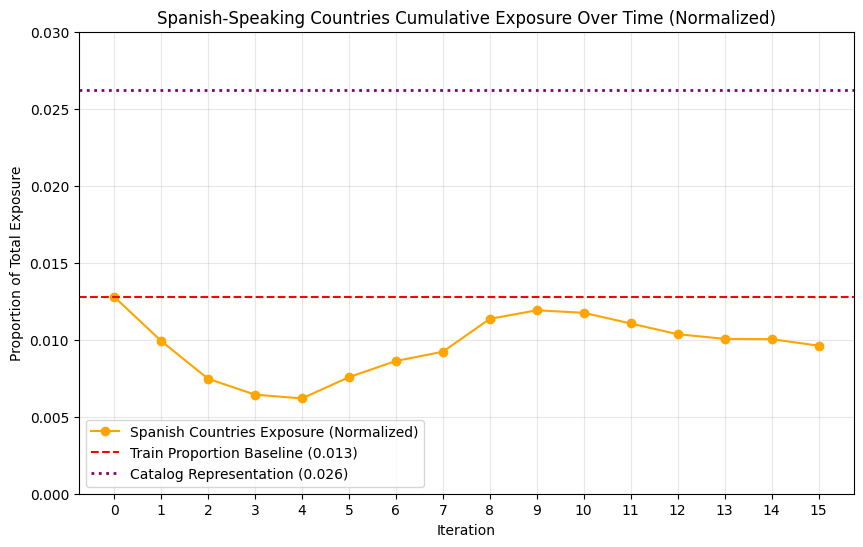

In [179]:
# Plot normalized cumulative exposure of Spanish countries over time
spanish_countries = countries_exposures.index.isin(["ES","MX","AR","CO","CL","PE","VE","EC","BO","PY","UY"])
exposure_over_time_spanish = countries_exposures[spanish_countries].sum(axis=0)
cumulative_exposure_spanish = exposure_over_time_spanish.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_spanish = cumulative_exposure_spanish / total_cumulative

# Calculate train proportion baseline from train_popularity in artist_exposures
spanish_train_popularity = artist_exposures[artist_exposures['country'].isin(spanish_countries_list)]['train_popularity'].sum()
total_train_popularity = artist_exposures['train_popularity'].sum()
train_proportion_spanish = spanish_train_popularity / total_train_popularity

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_spanish)), normalized_cumulative_spanish.values, marker='o', label='Spanish Countries Exposure (Normalized)', color='orange')
plt.axhline(y=train_proportion_spanish, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_spanish:.3f})')
plt.axhline(y=spanish_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({spanish_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('Spanish-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_spanish)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.03)
plt.show()


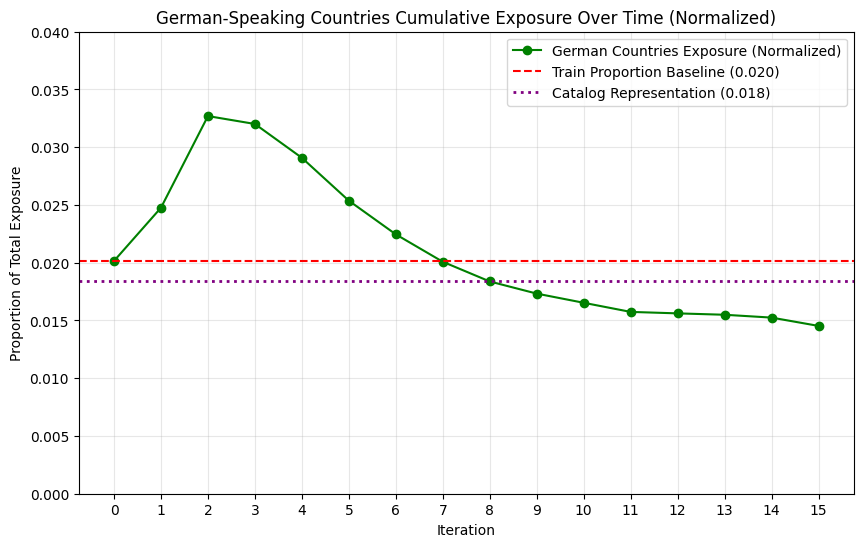

In [180]:
# Plot normalized cumulative exposure of German countries over time
german_countries = countries_exposures.index.isin(["DE","AT","CH","LI"])
exposure_over_time_german = countries_exposures[german_countries].sum(axis=0)
cumulative_exposure_german = exposure_over_time_german.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_german = cumulative_exposure_german / total_cumulative

# Calculate train proportion baseline from train_popularity in artist_exposures
german_train_popularity = artist_exposures[artist_exposures['country'].isin(german_countries_list)]['train_popularity'].sum()
total_train_popularity = artist_exposures['train_popularity'].sum()
train_proportion_german = german_train_popularity / total_train_popularity

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_german)), normalized_cumulative_german.values, marker='o', label='German Countries Exposure (Normalized)', color='green')
plt.axhline(y=train_proportion_german, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_german:.3f})')
plt.axhline(y=german_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({german_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('German-Speaking Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_german)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 0.04)
plt.show()


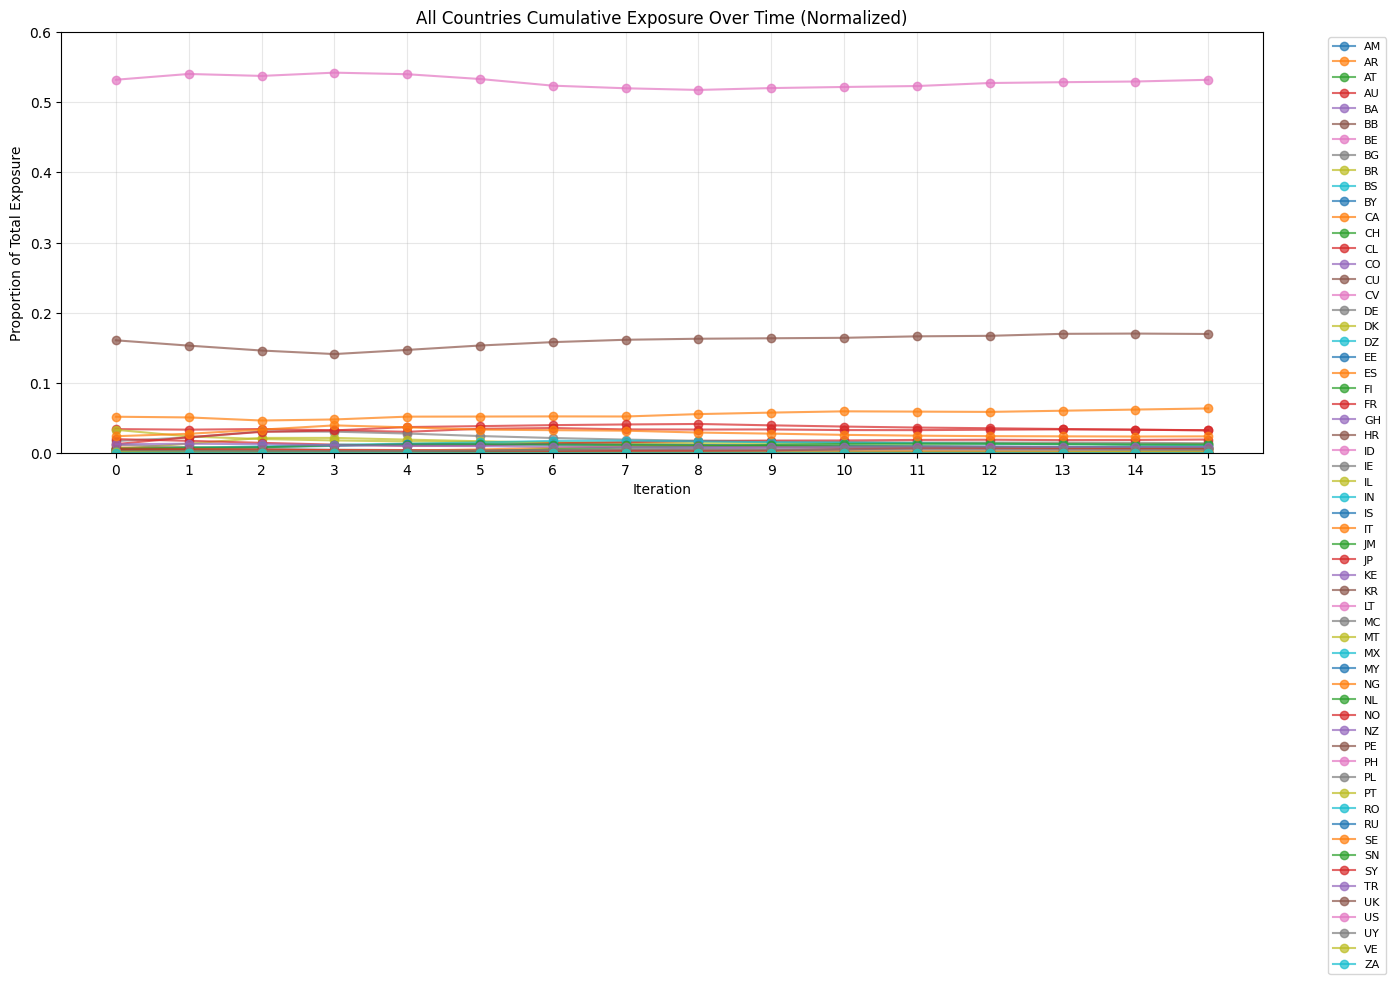

In [181]:
# Plot normalized cumulative exposure of all countries over time
plt.figure(figsize=(14, 8))

total_cumulative = countries_exposures.sum(axis=0).cumsum()

for country in countries_exposures.index:
    cumulative = countries_exposures.loc[country].cumsum()
    normalized = cumulative / total_cumulative
    plt.plot(range(len(normalized)), normalized.values, marker='o', label=country, alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('All Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(countries_exposures.columns)))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()

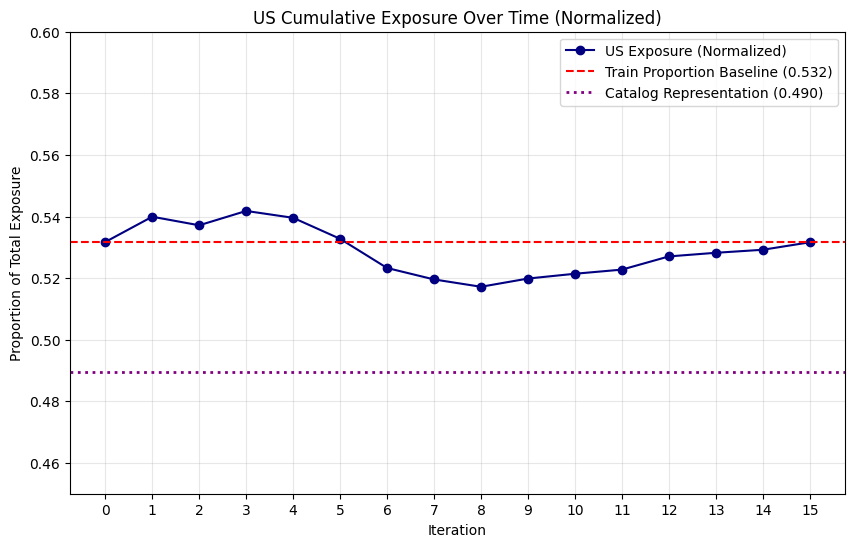

In [182]:
# Plot normalized cumulative exposure of US over time
us_countries = countries_exposures.index.isin(["US"])
exposure_over_time_us = countries_exposures[us_countries].sum(axis=0)
cumulative_exposure_us = exposure_over_time_us.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_us = cumulative_exposure_us / total_cumulative

# Calculate train proportion baseline from train_popularity in artist_exposures
us_train_popularity = artist_exposures[artist_exposures['country'].isin(["US"])]['train_popularity'].sum()
total_train_popularity = artist_exposures['train_popularity'].sum()
train_proportion_us = us_train_popularity / total_train_popularity

# Calculate US catalog representation
us_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(["US"])].sum()

plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_us)), normalized_cumulative_us.values, marker='o', label='US Exposure (Normalized)', color='navy')
plt.axhline(y=train_proportion_us, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_us:.3f})')
plt.axhline(y=us_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({us_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('US Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_us)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.45, 0.6)
plt.show()


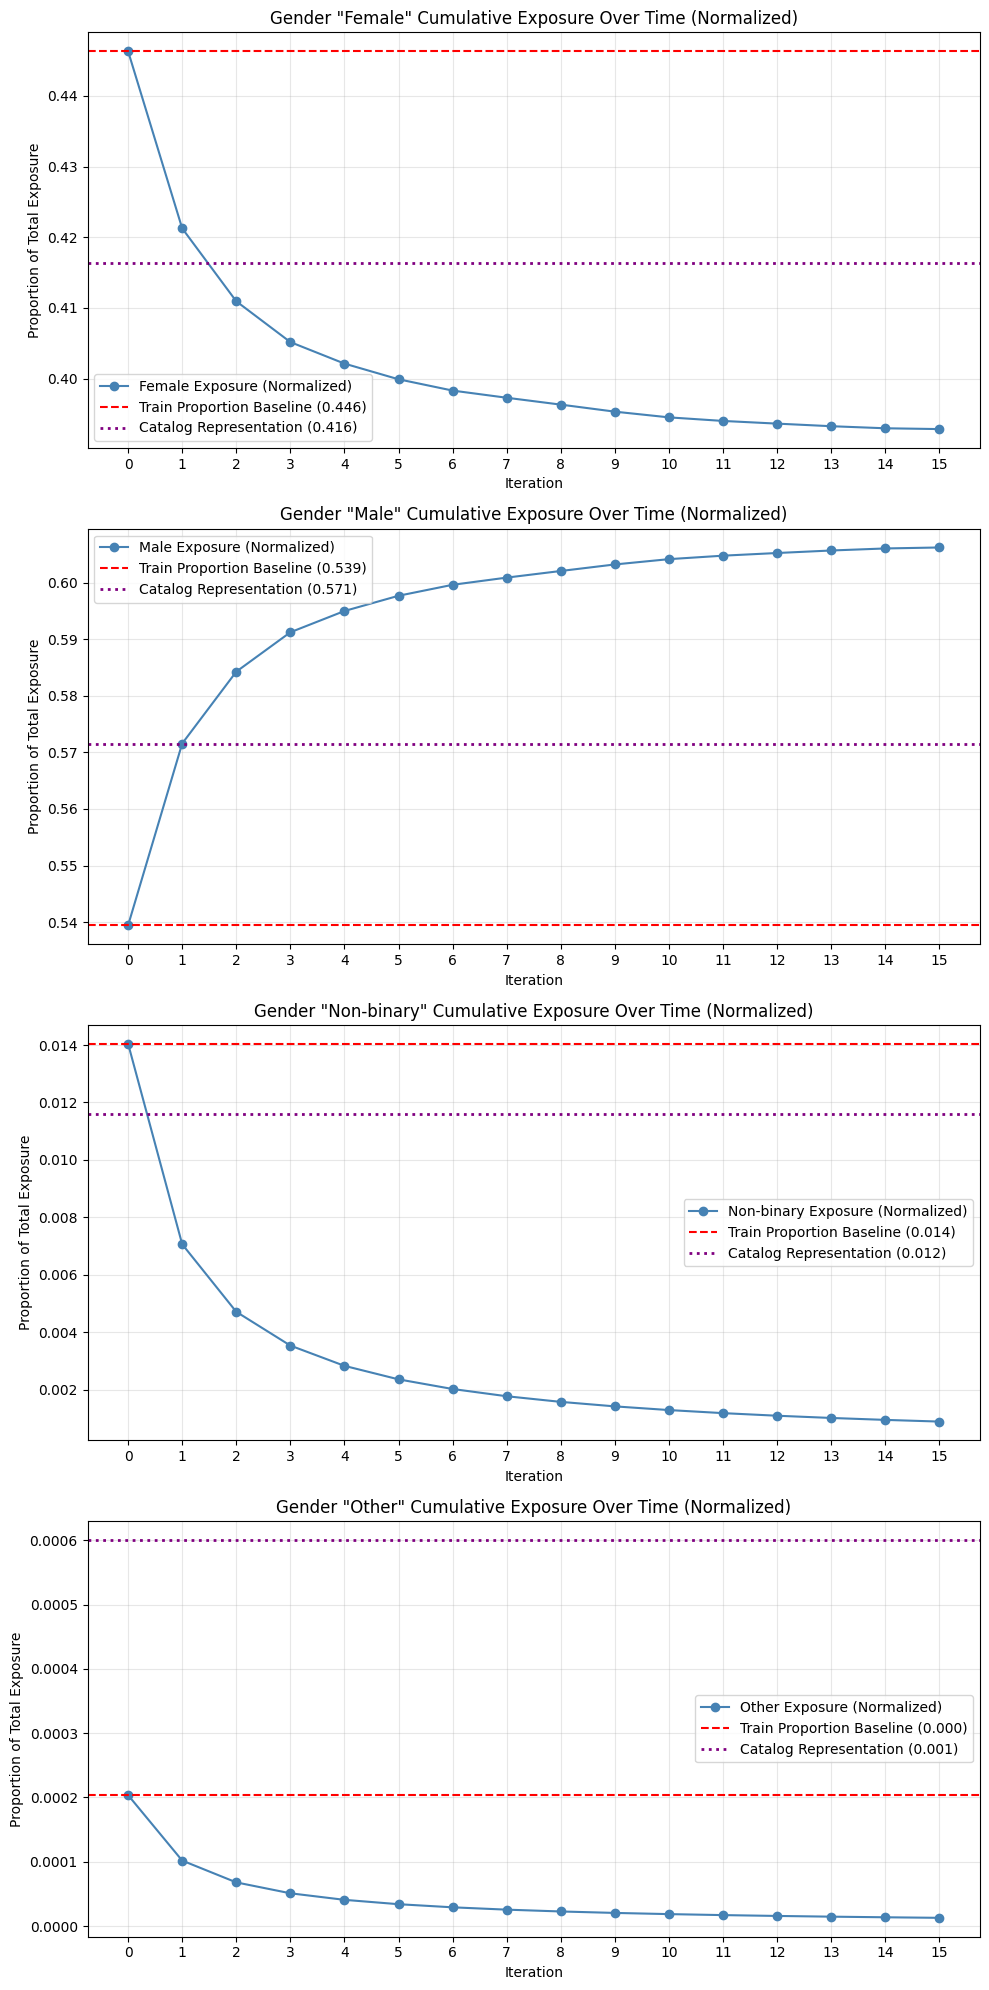

In [183]:
# Plot normalized cumulative exposure by artist gender over time
# First, create gender exposures similar to countries_exposures
gender_exposures = artist_exposures.iloc[:, [2] + list(range(3, artist_exposures.shape[1]))].groupby("gender").sum()

# Get unique genders
genders = gender_exposures.index.tolist()

# Calculate catalog gender representation
catalog_gender_representation = tracks_catalog.groupby("gender").size() / len(tracks_catalog)

# Create subplots for each gender
fig, axes = plt.subplots(len(genders), 1, figsize=(10, 5*len(genders)))

# Handle case where there's only one gender
if len(genders) == 1:
    axes = [axes]

for idx, gender in enumerate(genders):
    # Calculate cumulative exposure for this gender
    exposure_over_time_gender = gender_exposures.loc[gender]
    cumulative_exposure_gender = exposure_over_time_gender.cumsum()
    total_cumulative = gender_exposures.sum(axis=0).cumsum()
    normalized_cumulative_gender = cumulative_exposure_gender / total_cumulative
    
    # Calculate train proportion baseline
    gender_train_popularity = artist_exposures[artist_exposures['gender'] == gender]['train_popularity'].sum()
    total_train_popularity = artist_exposures['train_popularity'].sum()
    train_proportion_gender = gender_train_popularity / total_train_popularity
    
    # Calculate catalog representation for this gender
    gender_catalog_prop = catalog_gender_representation[catalog_gender_representation.index == gender].sum()
    
    # Plot
    axes[idx].plot(range(len(normalized_cumulative_gender)), normalized_cumulative_gender.values, marker='o', label=f'{gender} Exposure (Normalized)', color='steelblue')
    axes[idx].axhline(y=train_proportion_gender, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_gender:.3f})')
    axes[idx].axhline(y=gender_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({gender_catalog_prop:.3f})')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('Proportion of Total Exposure')
    axes[idx].set_title(f'Gender "{gender}" Cumulative Exposure Over Time (Normalized)')
    axes[idx].set_xticks(range(len(normalized_cumulative_gender)))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Plot non-cumulative (per-iteration) proportion of exposure by artist gender over time
total_exposure_per_iteration = gender_exposures.sum(axis=0)

fig, axes = plt.subplots(len(genders), 1, figsize=(10, 5*len(genders)))

# Handle case where there's only one gender
if len(genders) == 1:
    axes = [axes]

for idx, gender in enumerate(genders):
    # Per-iteration (not cumulative) exposure for this gender
    exposure_over_time_gender = gender_exposures.loc[gender]
    normalized_gender = exposure_over_time_gender / total_exposure_per_iteration

    # Calculate train proportion baseline
    gender_train_popularity = artist_exposures[artist_exposures['gender'] == gender]['train_popularity'].sum()
    total_train_popularity = artist_exposures['train_popularity'].sum()
    train_proportion_gender = gender_train_popularity / total_train_popularity

    # Calculate catalog representation for this gender
    gender_catalog_prop = catalog_gender_representation[catalog_gender_representation.index == gender].sum()

    # Plot
    axes[idx].plot(range(len(normalized_gender)), normalized_gender.values, marker='o', label=f'{gender} Exposure (Per-Iteration)', color='steelblue')
    axes[idx].axhline(y=train_proportion_gender, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_gender:.3f})')
    axes[idx].axhline(y=gender_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({gender_catalog_prop:.3f})')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('Proportion of Exposure (Per Iteration)')
    axes[idx].set_title(f'Gender "{gender}" Per-Iteration Exposure Over Time (Not Cumulative)')
    axes[idx].set_xticks(range(len(normalized_gender)))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


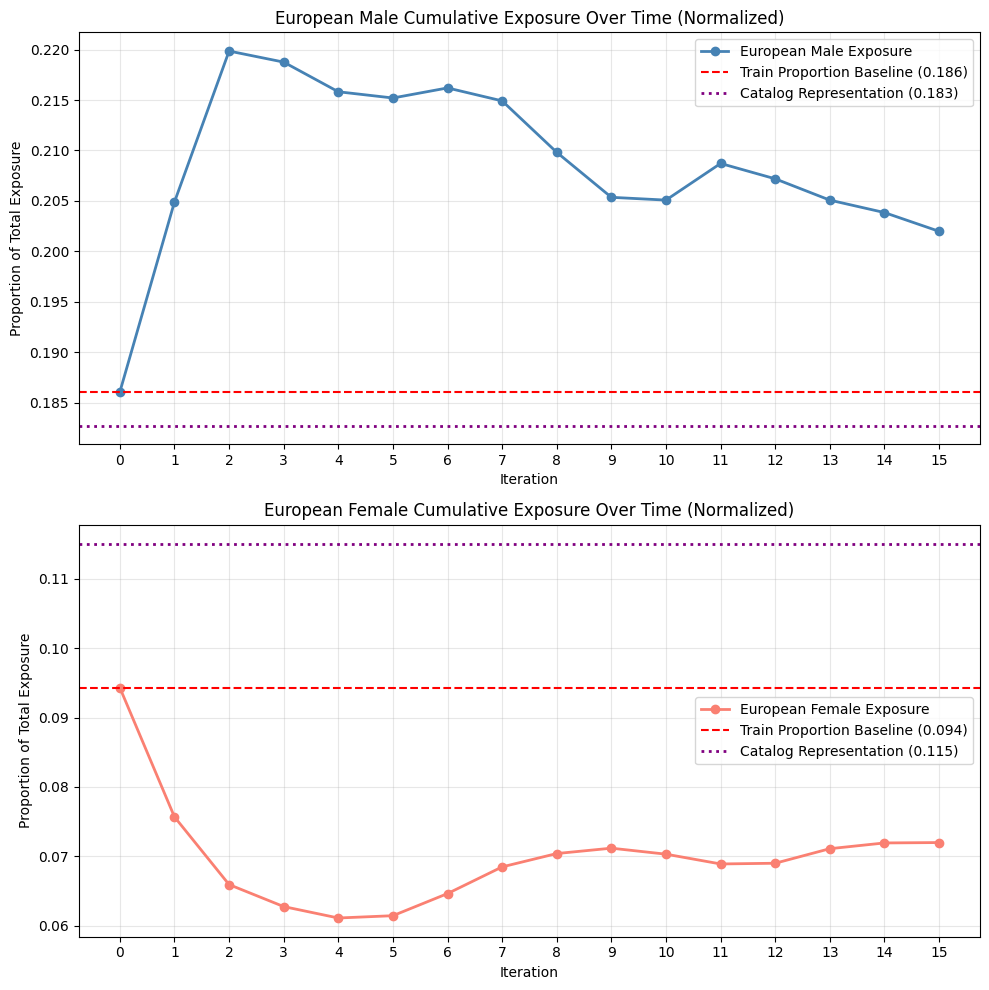

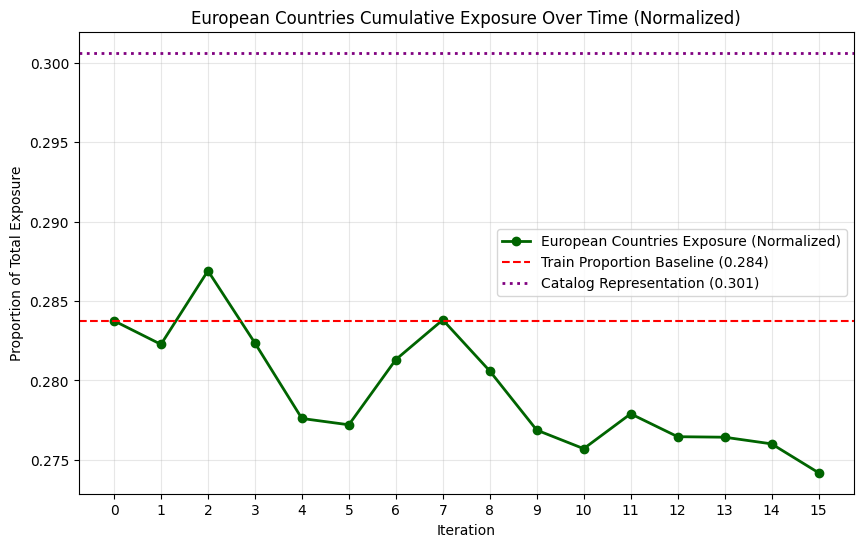

In [184]:
# Plot normalized cumulative exposure of European countries over time (with gender breakdown)
european_countries_list = ["DE", "AT", "CH", "LI", "FR", "BE", "NL", "PL", "SE", "NO", "DK", "FI", "IE", "UK", "IT", "ES", "PT", "GR", "RO", "CZ", "HU", "HR", "BA", "SY", "TR"]
european_countries = countries_exposures.index.isin(european_countries_list)
exposure_over_time_europe = countries_exposures[european_countries].sum(axis=0)
cumulative_exposure_europe = exposure_over_time_europe.cumsum()
total_cumulative = countries_exposures.sum(axis=0).cumsum()
normalized_cumulative_europe = cumulative_exposure_europe / total_cumulative

# Calculate European male exposure
european_male_df = artist_exposures[(artist_exposures['country'].isin(european_countries_list)) & (artist_exposures['gender'] == 'Male')]
exposure_over_time_europe_male = european_male_df.iloc[:, 3:].sum(axis=0)
cumulative_exposure_europe_male = exposure_over_time_europe_male.cumsum()
normalized_cumulative_europe_male = cumulative_exposure_europe_male / total_cumulative

# Calculate European female exposure
european_female_df = artist_exposures[(artist_exposures['country'].isin(european_countries_list)) & (artist_exposures['gender'] == 'Female')]
exposure_over_time_europe_female = european_female_df.iloc[:, 3:].sum(axis=0)
cumulative_exposure_europe_female = exposure_over_time_europe_female.cumsum()
normalized_cumulative_europe_female = cumulative_exposure_europe_female / total_cumulative

# Calculate train proportion baseline from train_popularity in artist_exposures
europe_train_popularity = artist_exposures[artist_exposures['country'].isin(european_countries_list)]['train_popularity'].sum()
total_train_popularity = artist_exposures['train_popularity'].sum()
train_proportion_europe = europe_train_popularity / total_train_popularity

# Calculate European catalog representation
europe_catalog_prop = catalog_countries_representation[catalog_countries_representation.index.isin(european_countries_list)].sum()

# Calculate train proportions by gender for European artists
europe_male_train_popularity = european_male_df['train_popularity'].sum()
train_proportion_europe_male = europe_male_train_popularity / total_train_popularity

europe_female_train_popularity = european_female_df['train_popularity'].sum()
train_proportion_europe_female = europe_female_train_popularity / total_train_popularity

# Calculate catalog representation for European male and female artists
europe_male_catalog = tracks_catalog[(tracks_catalog['country'].isin(european_countries_list)) & (tracks_catalog['gender'] == 'Male')].shape[0] / len(tracks_catalog)
europe_female_catalog = tracks_catalog[(tracks_catalog['country'].isin(european_countries_list)) & (tracks_catalog['gender'] == 'Female')].shape[0] / len(tracks_catalog)

# Create subplots for European Male and Female
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot European Male
axes[0].plot(range(len(normalized_cumulative_europe_male)), normalized_cumulative_europe_male.values, marker='o', label='European Male Exposure', color='steelblue', linewidth=2)
axes[0].axhline(y=train_proportion_europe_male, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_europe_male:.3f})')
axes[0].axhline(y=europe_male_catalog, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({europe_male_catalog:.3f})')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Proportion of Total Exposure')
axes[0].set_title('European Male Cumulative Exposure Over Time (Normalized)')
axes[0].set_xticks(range(len(normalized_cumulative_europe_male)))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot European Female
axes[1].plot(range(len(normalized_cumulative_europe_female)), normalized_cumulative_europe_female.values, marker='o', label='European Female Exposure', color='salmon', linewidth=2)
axes[1].axhline(y=train_proportion_europe_female, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_europe_female:.3f})')
axes[1].axhline(y=europe_female_catalog, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({europe_female_catalog:.3f})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Proportion of Total Exposure')
axes[1].set_title('European Female Cumulative Exposure Over Time (Normalized)')
axes[1].set_xticks(range(len(normalized_cumulative_europe_female)))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot overall European exposure
plt.figure(figsize=(10, 6))
plt.plot(range(len(normalized_cumulative_europe)), normalized_cumulative_europe.values, marker='o', label='European Countries Exposure (Normalized)', color='darkgreen', linewidth=2)
plt.axhline(y=train_proportion_europe, color='r', linestyle='--', label=f'Train Proportion Baseline ({train_proportion_europe:.3f})')
plt.axhline(y=europe_catalog_prop, color='purple', linestyle=':', linewidth=2, label=f'Catalog Representation ({europe_catalog_prop:.3f})')
plt.xlabel('Iteration')
plt.ylabel('Proportion of Total Exposure')
plt.title('European Countries Cumulative Exposure Over Time (Normalized)')
plt.xticks(range(len(normalized_cumulative_europe)))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()